# Practical 04: Titanic Survival Prediction

## Dataset: Titanic Dataset
## Subject: Machine Learning

Objective: Predict survival of passengers using classification techniques.


## Import Libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Load Dataset

In [7]:
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Cleaning

In [8]:
df.drop(["PassengerId","Name","Ticket","Cabin"], axis=1, inplace=True)

df["Age"].fillna(df["Age"].mean(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df = pd.get_dummies(df, columns=["Sex","Embarked"])

df.head()

/tmp/ipykernel_58044/3268565124.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)
/tmp/ipykernel_58044/3268565124.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,0,3,35.0,0,0,8.0500,False,True,False,False,True


## Feature & Target Split

In [9]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

## Train-Test Split

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

## Feature Scaling

In [11]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Model Training (Logistic Regression)

In [12]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

## Prediction

In [13]:
y_pred = model.predict(X_test)

## Evaluation

In [14]:
cm = confusion_matrix(y_test,y_pred)
acc = accuracy_score(y_test,y_pred)

print("Accuracy:",acc)
print("Confusion Matrix:\n",cm)

Accuracy: 0.8071748878923767
Confusion Matrix:
 [[115  19]
 [ 24  65]]


## Confusion Matrix Visualization

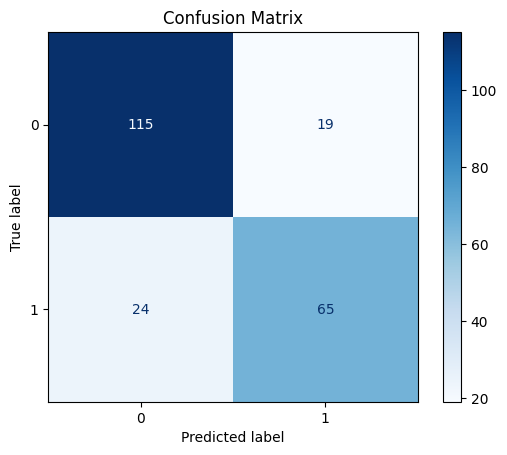

In [15]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

## Data Visualization

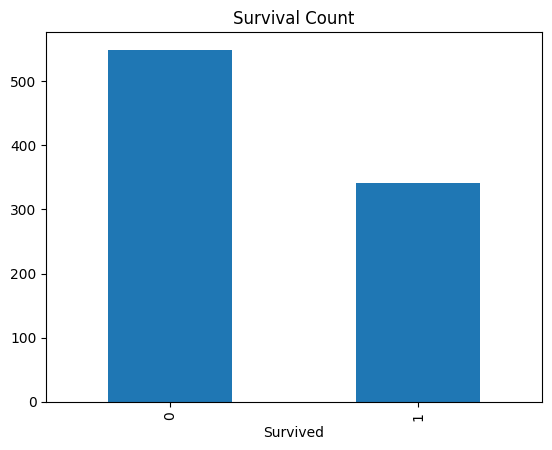

In [16]:
plt.figure()
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.show()

## Conclusion

Logistic Regression was successfully applied to predict passenger survival. Data preprocessing and feature engineering improved model performance, achieving good classification accuracy.